# (Optional) Step 0: Download data from Public data bases

This notebook builds a model ready bioactivity dataset for a set of biological targets. It is target agnostic like viral, bacterial, enzyme, receptor targets by editing the configuration cell alone.

The pipeline runs in following stages:

1. **Read bioactivity data from local files** for each target and clean it into a consistent schema.
2. **Combine** the per-target tables into one dataset.
3. **Standardize potency** by converting concentration endpoints to micromolar and then to a log potency scale (`pPotency`).
4. **Ingest PubChem data** (from local exports or the PubChem/NCBI APIs) and bring it onto the same scale.
5. **Canonicalize SMILES** and filter to valid, in-range records.

Everything you are likely to change lives in the single configuration cell
below. Paths, target names, thresholds, and feature toggles are all set there so
the analysis cells stay untouched between projects.

### Imports

In [6]:
import os
import io
import re
import csv
import time
import random
import zipfile
import glob
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from rdkit import Chem
from rdkit.Chem import (
    AllChem,
    DataStructs,
    Descriptors,
    Crippen,
    Lipinski,
    MACCSkeys,
    rdMolDescriptors,
)
from rdkit.Chem import rdFingerprintGenerator as FPgen
from rdkit.Chem.QED import qed

### Configuration

Point the paths at your own data, list your targets and toggle the feature blocks you need. The analysis
cells below read from `CONFIG` and should not need be changed.

In [7]:
CONFIG = {
    # -----------------------------------------------
    # Project speficic configuration (user defined)
    # -----------------------------------------------
    # List the targets to combine into one master dataset. For a viral master set
    # list the viruses; for a bacterial master set list the bacteria. Names must
    # match the per-target folder names under ChEMBL_data and PubChem_data. 
    "targets": [
        "Ebola",
        "Marburg",
        "Lassa",
        "Nipah",
        "VEEV",
        "Hanta",
        "SARS-CoV",
        "SARS-CoV-2",
    ],

    # Label this to create the output folder (Results_<label>)
    "datasetLabel": "Ebola",

    # ----------------------------------------
    # Stable configuration (do not change)
    # ----------------------------------------

    # Input root and the per-database subfolders inside it.
    "dataDir": os.environ.get("DRUG_DESIGN_DATA_DIR", "Database_Data_Raw"),
    "chemblSubdir": "ChEMBL_data",
    "pubchemSubdir": "PubChem_data",

    # Compound identifier, SMILES, and label columns used throughout featurization.
    "idColumn": "molecule_chembl_id",
    "smilesColumn": "smiles",
    "labelColumn": "pPotency",

    # pPotency is p = pScaleOffset - log10(value in micromolar), which equals
    # -log10(value in molar). Keep at 6.0 for micromolar input.
    "pScaleOffset": 6.0,

    # Keep only physically sensible potency values after conversion.
    "pPotencyMin": 0.0,
    "pPotencyMax": 12.0,

    # Fingerprint settings.
    "ecfpRadius": 2,
    "ecfpBits": 2048,

    # PubChem / NCBI E-utilities settings.
    # TODO: set your own contact email; NCBI requests one for API traffic.
    "ncbiEmail": "sghosh6@lbl.gov",
    # TODO: set your own NCBI API key for high-throughput calls, else "".
    # Never commit a real key to version control.
    "ncbiApiKey": "0ffd39fe99552944ce9a9204efef27be7109",
    "ncbiTool": "drugDesignHarvester",
    "aidsPerTarget": 150,

    # Reproducibility.
    "randomSeed": 42,
}

# Input locations derive from dataDir and the per-database subfolders.
dataDir = CONFIG["dataDir"]
chemblDir = os.path.join(dataDir, CONFIG["chemblSubdir"])
pubchemDir = os.path.join(dataDir, CONFIG["pubchemSubdir"])
cleanedInputDataDir = os.path.join("Database_Data_Cleaned")

# Create the input root and the output folder if they are not already present.
os.makedirs(dataDir, exist_ok=True)
os.makedirs(cleanedInputDataDir, exist_ok=True)

print("Input data directory:", os.path.abspath(dataDir))
print("Input data sub-directory for ChEMBL data:", os.path.abspath(chemblDir))
print("Input data sub-directory for PubChem data:", os.path.abspath(pubchemDir))
print("Results directory:", os.path.abspath(cleanedInputDataDir))
print(f"Master dataset include {len(CONFIG['targets'])} targets:",
      ", ".join(CONFIG["targets"]))

Input data directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Database_Data_Raw
Input data sub-directory for ChEMBL data: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Database_Data_Raw/ChEMBL_data
Input data sub-directory for PubChem data: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Database_Data_Raw/PubChem_data
Results directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Database_Data_Cleaned
Master dataset include 8 targets: Ebola, Marburg, Lassa, Nipah, VEEV, Hanta, SARS-CoV, SARS-CoV-2


## 1. Read and clean bioactivity data (Downloaded from `ChEMBL` data base)

In [8]:
def readChemblCsvFile(filePath):
    """Read a ChEMBL CSV export that uses a semicolon delimiter and quoted fields."""
    print(f"Reading ChEMBL CSV file: {filePath}")
    if not os.path.exists(filePath):
        print(f"Error: File not found at {filePath}")
        return None
    try:
        dataFrame = pd.read_csv(
            filePath,
            sep=";",
            quotechar='"',
            quoting=csv.QUOTE_ALL,
            doublequote=True,
            skipinitialspace=True,
            on_bad_lines="skip",
            encoding="utf-8",
            low_memory=False,
        )
        return dataFrame
    except Exception as error:
        print(f"Standard pandas read failed: {error}")
        return None


def splitSemicolonRobust(line):
    """Split a line on semicolons while respecting quoted fields and escaped quotes."""
    fields, current = [], []
    inQuote = False
    i = 0
    while i < len(line):
        char = line[i]
        if char == '"':
            if inQuote and i + 1 < len(line) and line[i + 1] == '"':
                current.append('"')
                i += 2
                continue
            inQuote = not inQuote
            i += 1
            continue
        if char == ";" and not inQuote:
            fields.append("".join(current))
            current = []
            i += 1
            continue
        current.append(char)
        i += 1
    fields.append("".join(current))
    return fields

In [9]:
def processTargetChemblData(targetName, targetDataDir, outputDir):
    """Clean and combine one target's ChEMBL bioassay and compound exports.

    Reads {targetName}_bioactivity.csv and {targetName}_compounds.csv from
    targetDataDir, writes cleaned and combined CSVs to outputDir, and saves a
    standard-type distribution plot. Returns the combined DataFrame, or None if
    inputs are missing.
    """
    if not os.path.exists(targetDataDir):
        print(f"Error: data directory for '{targetName}' not found at {targetDataDir}")
        return None

    print("\nProcessing bioassay data")
    bioactivityFile = os.path.join(targetDataDir, f"{targetName}_bioactivity.csv")
    chemblData = readChemblCsvFile(bioactivityFile)
    if chemblData is None:
        return None
    print(f"Loaded bioassay data with shape: {chemblData.shape}")

    selectedColumns = [
        "Smiles", "Standard Value", "Standard Units", "Standard Type",
        "Standard Relation", "pChEMBL Value", "Molecule ChEMBL ID",
        "Molecular Weight", "AlogP", "Target ChEMBL ID",
        "Target Name", "Target Organism",
    ]
    chemblDataCleaned = chemblData[
        [col for col in selectedColumns if col in chemblData.columns]
    ].copy()
    print(f"Shape after selecting columns: {chemblData.shape} to {chemblDataCleaned.shape}")

    outputPath = os.path.join(outputDir, f"{targetName}Bioassay_chEMBL_cleaned.csv")
    chemblDataCleaned.to_csv(outputPath, index=False)
    print(f"Saved cleaned bioassay data to: {outputPath}")

    # Also save the cleaned bioactivity table into cleaned_Input_Data with the
    # {targetName}_bioactivity.csv naming, mirroring the raw input layout.
    cleanedBioactivityPath = os.path.join(cleanedInputDataDir, f"{targetName}_bioactivity.csv")
    chemblDataCleaned.to_csv(cleanedBioactivityPath, index=False)
    print(f"Saved cleaned bioactivity file to: {cleanedBioactivityPath}")

    print("\nAnalyzing standard types")
    typeCounts = chemblDataCleaned["Standard Type"].value_counts()
    total = typeCounts.sum()
    legendLabels = [
        f"{stype} ({count}, {count / total:.1%})" for stype, count in typeCounts.items()
    ]
    plt.figure(figsize=(10, 8))
    wedges, _texts, _autotexts = plt.pie(
        typeCounts, labels=typeCounts.index, autopct="%1.1f%%",
        startangle=140, wedgeprops={"edgecolor": "black"}, textprops={"fontsize": 9},
    )
    plt.legend(
        wedges, legendLabels, title="Standard Type",
        loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
    )
    plt.title(f"Distribution of standard types for {targetName}")
    plt.tight_layout()
    plotPath = os.path.join(outputDir, f"{targetName}_standard_types.png")
    plt.savefig(plotPath)
    print(f"Saved standard-type plot to: {plotPath}")
    plt.show()
    plt.close()

    print("\nChecking for missing values")
    nanCounts = chemblDataCleaned.isnull().sum()
    totalRows = len(chemblDataCleaned)
    for column, nanCount in nanCounts.items():
        percentage = (nanCount / totalRows) * 100 if totalRows else 0.0
        print(f"{column:25s}: {nanCount:6,} ({percentage:5.1f}%)")

    if "Molecule ChEMBL ID" in chemblDataCleaned.columns:
        uniqueCount = chemblDataCleaned["Molecule ChEMBL ID"].nunique()
        print(f"\nUnique compounds for {targetName}: {uniqueCount}")

    print("\nProcessing compound data")
    compoundsFile = os.path.join(targetDataDir, f"{targetName}_compounds.csv")
    if not os.path.exists(compoundsFile):
        print(f"Error: compounds file not found at {compoundsFile}")
        return None

    chemblCompoundData = readChemblCsvFile(compoundsFile)
    if chemblCompoundData is None:
        return None

    chemblCompoundData.columns = [
        re.sub(r"[^\w]+", "_", col).strip("_").lower() for col in chemblCompoundData.columns
    ]
    if "molecule_chembl_id" in chemblCompoundData.columns:
        chemblCompoundData = chemblCompoundData.rename(
            columns={"molecule_chembl_id": "chembl_id"}
        )

    numericCols = [
        "molecular_weight", "alogp", "polar_surface_area", "hba", "hbd",
        "ro5_violations", "rotatable_bonds", "qed_weighted", "heavy_atoms",
    ]
    for col in numericCols:
        if col in chemblCompoundData.columns:
            chemblCompoundData[col] = pd.to_numeric(chemblCompoundData[col], errors="coerce")

    print(f"Compound data shape: {chemblCompoundData.shape}")
    outputPath = os.path.join(outputDir, f"{targetName}Compounds_chEMBL_cleaned.csv")
    chemblCompoundData.to_csv(outputPath, index=False)
    print(f"Saved cleaned compound data to: {outputPath}")

    print("\nCombining bioassay and compound data")
    colsToImport = [
        "chembl_id", "type", "polar_surface_area", "hba", "hbd", "rotatable_bonds",
        "qed_weighted", "heavy_atoms", "aromatic_rings", "ro5_violations",
        "molecular_formula", "inchi_key", "inchi",
    ]
    cmpdSub = chemblCompoundData.loc[
        :, [col for col in colsToImport if col in chemblCompoundData.columns]
    ].copy()

    chemblDataCombined = chemblDataCleaned.merge(
        cmpdSub, how="left", left_on="Molecule ChEMBL ID", right_on="chembl_id",
        suffixes=("", "_cmp"),
    )
    if "chembl_id" in chemblDataCombined.columns:
        chemblDataCombined = chemblDataCombined.drop(columns=["chembl_id"])

    chemblDataCombined = chemblDataCombined.rename(columns={
        "Smiles": "smiles", "Standard Value": "standard_value",
        "Standard Units": "standard_units", "Standard Type": "standard_type",
        "Standard Relation": "standard_relation", "pChEMBL Value": "pchembl_value",
        "Molecule ChEMBL ID": "molecule_chembl_id", "Molecular Weight": "molecular_weight",
    })

    desiredOrder = [
        "molecule_chembl_id", "smiles", "molecular_formula", "inchi_key", "inchi",
        "molecular_weight", "type", "standard_value", "standard_units",
        "standard_relation", "standard_type", "pchembl_value", "AlogP",
        "polar_surface_area", "hba", "hbd", "rotatable_bonds", "qed_weighted",
        "heavy_atoms", "aromatic_rings", "ro5_violations", "Target ChEMBL ID",
        "Target Name", "Target Organism",
    ]
    existing = [col for col in desiredOrder if col in chemblDataCombined.columns]
    extras = [col for col in chemblDataCombined.columns if col not in existing]
    chemblDataCombined = chemblDataCombined[existing + extras]

    outputPath = os.path.join(outputDir, f"{targetName}Data_chEMBL_combined.csv")
    chemblDataCombined.to_csv(outputPath, index=False)
    print(f"Saved combined data to: {outputPath} with shape {chemblDataCombined.shape}")
    return chemblDataCombined

Run the cleaner over every configured target. Each target folder is expected
at `{dataDir}/{targetName}` and to contain `{targetName}_bioactivity.csv` and
`{targetName}_compounds.csv`. Targets with missing files are skipped.


Processing bioassay data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/Ebola/Ebola_bioactivity.csv
Loaded bioassay data with shape: (956, 48)
Shape after selecting columns: (956, 48) to (956, 12)
Saved cleaned bioassay data to: Database_Data_Cleaned/EbolaBioassay_chEMBL_cleaned.csv
Saved cleaned bioactivity file to: Database_Data_Cleaned/Ebola_bioactivity.csv

Analyzing standard types
Saved standard-type plot to: Database_Data_Cleaned/Ebola_standard_types.png


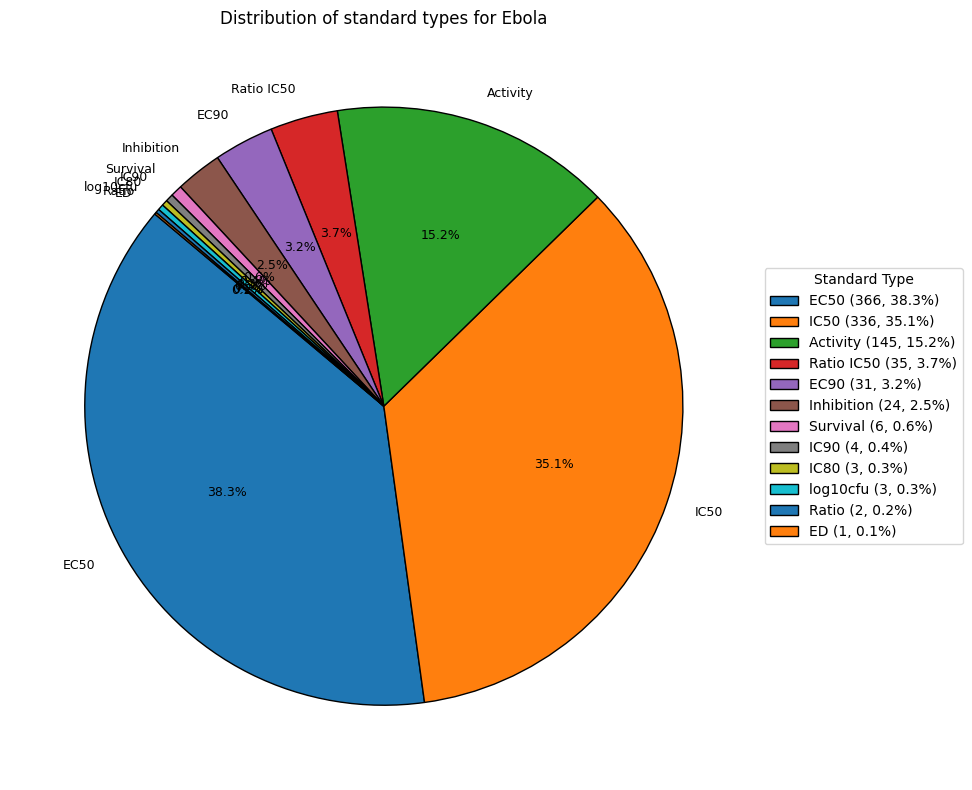


Checking for missing values
Smiles                   :      0 (  0.0%)
Standard Value           :     75 (  7.8%)
Standard Units           :    106 ( 11.1%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     75 (  7.8%)
pChEMBL Value            :    347 ( 36.3%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      6 (  0.6%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Unique compounds for Ebola: 582

Processing compound data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/Ebola/Ebola_compounds.csv
Compound data shape: (582, 29)
Saved cleaned compound data to: Database_Data_Cleaned/EbolaCompounds_chEMBL_cleaned.csv

Combining bioassay and compound data
Saved combined data to: Database_Data_Cleaned/EbolaData_chEMBL_combined.csv with shape (956, 24)
Ebola: 0.4s

Processing bioassay data
Reading ChEMBL CSV file

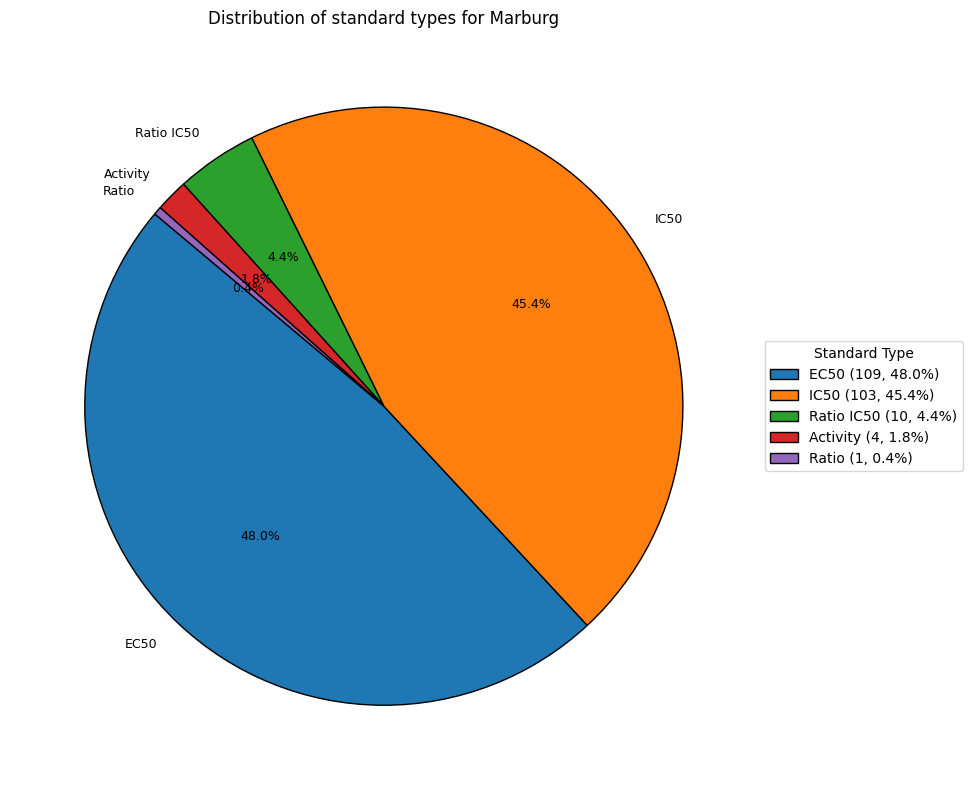


Checking for missing values
Smiles                   :      0 (  0.0%)
Standard Value           :     12 (  5.3%)
Standard Units           :     23 ( 10.1%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     12 (  5.3%)
pChEMBL Value            :     48 ( 21.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Unique compounds for Marburg: 170

Processing compound data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/Marburg/Marburg_compounds.csv
Compound data shape: (170, 29)
Saved cleaned compound data to: Database_Data_Cleaned/MarburgCompounds_chEMBL_cleaned.csv

Combining bioassay and compound data
Saved combined data to: Database_Data_Cleaned/MarburgData_chEMBL_combined.csv with shape (227, 24)
Marburg: 0.2s

Processing bioassay data
Reading ChE

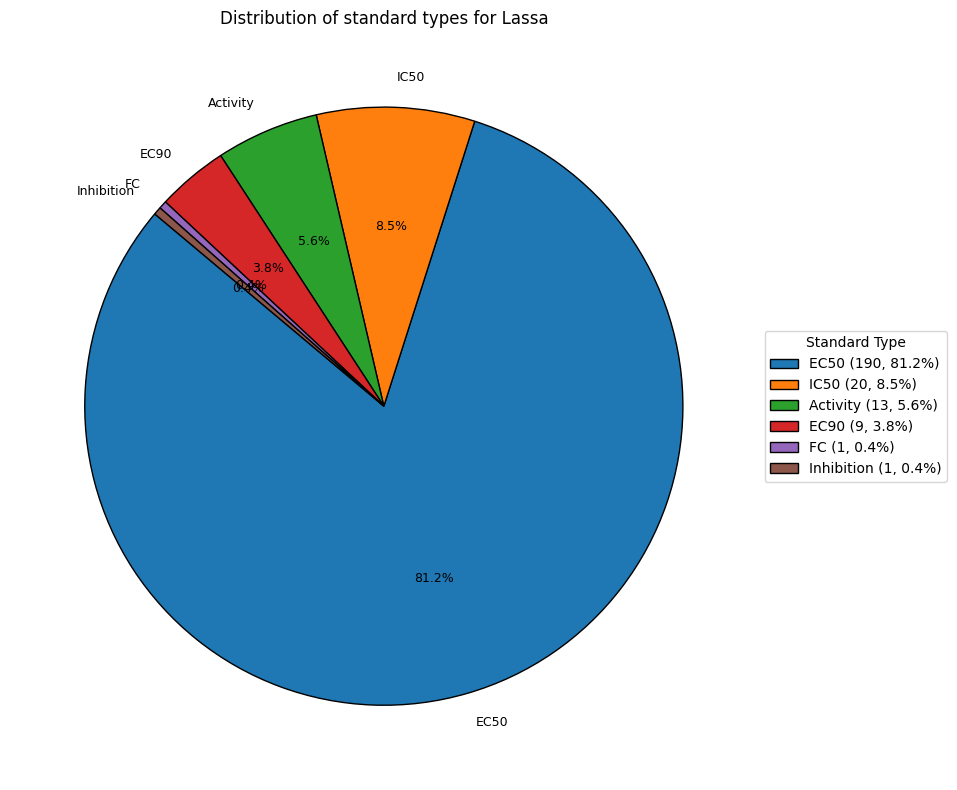


Checking for missing values
Smiles                   :      0 (  0.0%)
Standard Value           :     14 (  6.0%)
Standard Units           :     14 (  6.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     14 (  6.0%)
pChEMBL Value            :     46 ( 19.7%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Unique compounds for Lassa: 211

Processing compound data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/Lassa/Lassa_compounds.csv
Compound data shape: (211, 29)
Saved cleaned compound data to: Database_Data_Cleaned/LassaCompounds_chEMBL_cleaned.csv

Combining bioassay and compound data
Saved combined data to: Database_Data_Cleaned/LassaData_chEMBL_combined.csv with shape (234, 24)
Lassa: 0.2s

Processing bioassay data
Reading ChEMBL CSV file

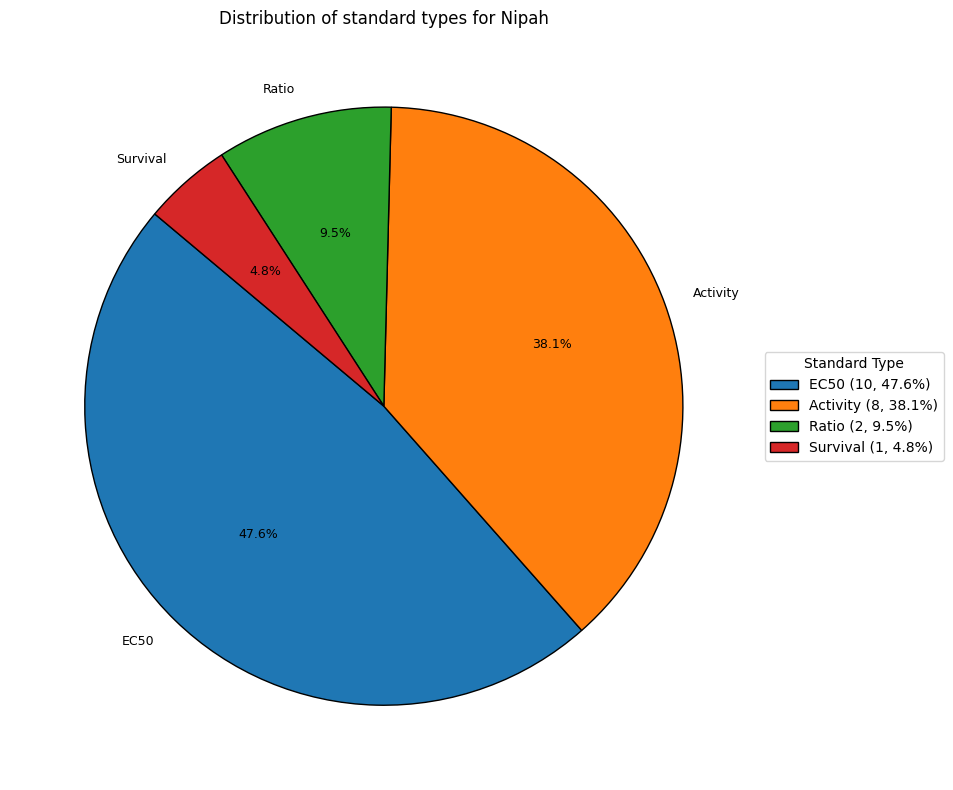


Checking for missing values
Smiles                   :      0 (  0.0%)
Standard Value           :      8 ( 38.1%)
Standard Units           :     10 ( 47.6%)
Standard Type            :      0 (  0.0%)
Standard Relation        :      8 ( 38.1%)
pChEMBL Value            :     11 ( 52.4%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Unique compounds for Nipah: 12

Processing compound data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/Nipah/Nipah_compounds.csv
Compound data shape: (12, 29)
Saved cleaned compound data to: Database_Data_Cleaned/NipahCompounds_chEMBL_cleaned.csv

Combining bioassay and compound data
Saved combined data to: Database_Data_Cleaned/NipahData_chEMBL_combined.csv with shape (21, 24)
Nipah: 0.2s

Processing bioassay data
Reading ChEMBL CSV file: D

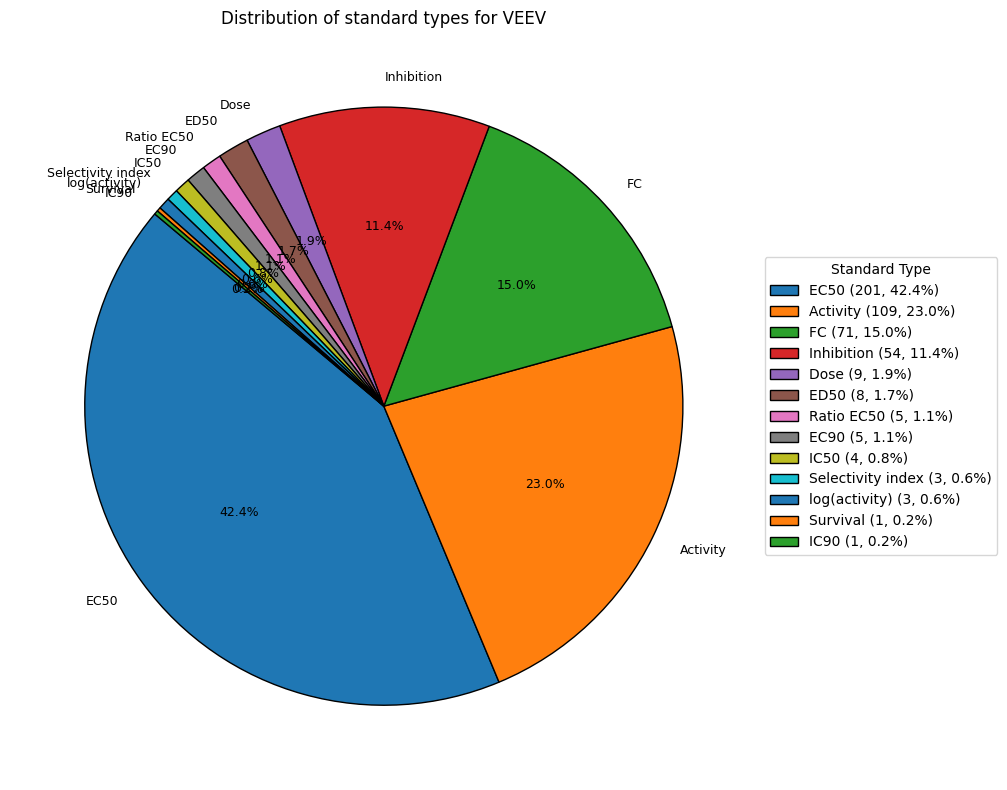


Checking for missing values
Smiles                   :      0 (  0.0%)
Standard Value           :    112 ( 23.6%)
Standard Units           :    147 ( 31.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :    112 ( 23.6%)
pChEMBL Value            :    337 ( 71.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      1 (  0.2%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Unique compounds for VEEV: 275

Processing compound data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/VEEV/VEEV_compounds.csv
Compound data shape: (275, 29)
Saved cleaned compound data to: Database_Data_Cleaned/VEEVCompounds_chEMBL_cleaned.csv

Combining bioassay and compound data
Saved combined data to: Database_Data_Cleaned/VEEVData_chEMBL_combined.csv with shape (474, 24)
VEEV: 0.4s

Processing bioassay data
Reading ChEMBL CSV file: Data

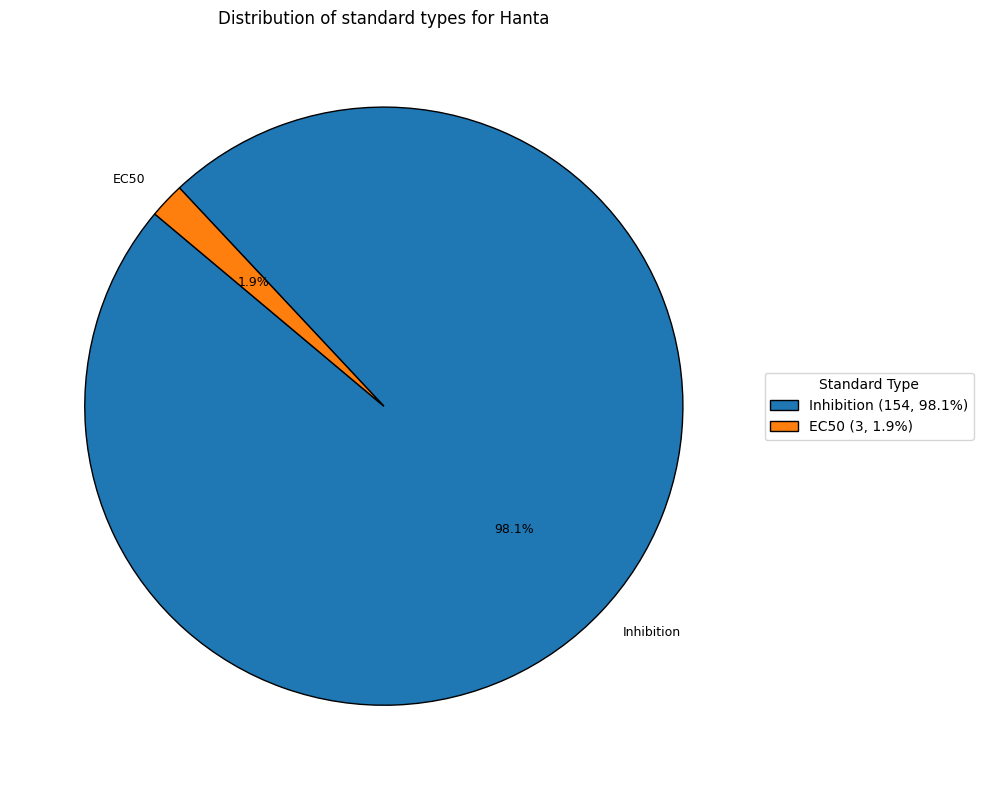


Checking for missing values
Smiles                   :      0 (  0.0%)
Standard Value           :     35 ( 22.3%)
Standard Units           :      0 (  0.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     35 ( 22.3%)
pChEMBL Value            :    154 ( 98.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      1 (  0.6%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Unique compounds for Hanta: 119

Processing compound data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/Hanta/Hanta_compounds.csv
Compound data shape: (119, 29)
Saved cleaned compound data to: Database_Data_Cleaned/HantaCompounds_chEMBL_cleaned.csv

Combining bioassay and compound data
Saved combined data to: Database_Data_Cleaned/HantaData_chEMBL_combined.csv with shape (157, 24)
Hanta: 0.2s

Processing bioassay data
Reading ChEMBL CSV file

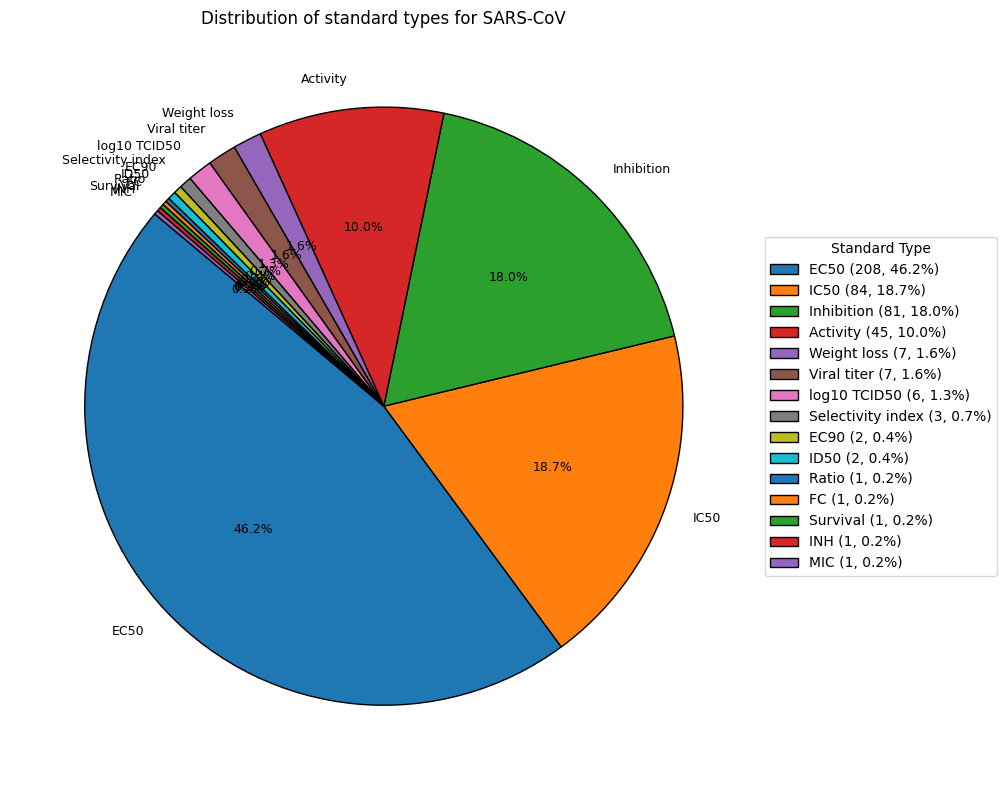


Checking for missing values
Smiles                   :      0 (  0.0%)
Standard Value           :     76 ( 16.9%)
Standard Units           :     71 ( 15.8%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     76 ( 16.9%)
pChEMBL Value            :    234 ( 52.0%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :     14 (  3.1%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Unique compounds for SARS-CoV: 246

Processing compound data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/SARS-CoV/SARS-CoV_compounds.csv
Compound data shape: (242, 29)
Saved cleaned compound data to: Database_Data_Cleaned/SARS-CoVCompounds_chEMBL_cleaned.csv

Combining bioassay and compound data
Saved combined data to: Database_Data_Cleaned/SARS-CoVData_chEMBL_combined.csv with shape (450, 24)
SARS-CoV: 0.4s

Processing bioassay data
Readi

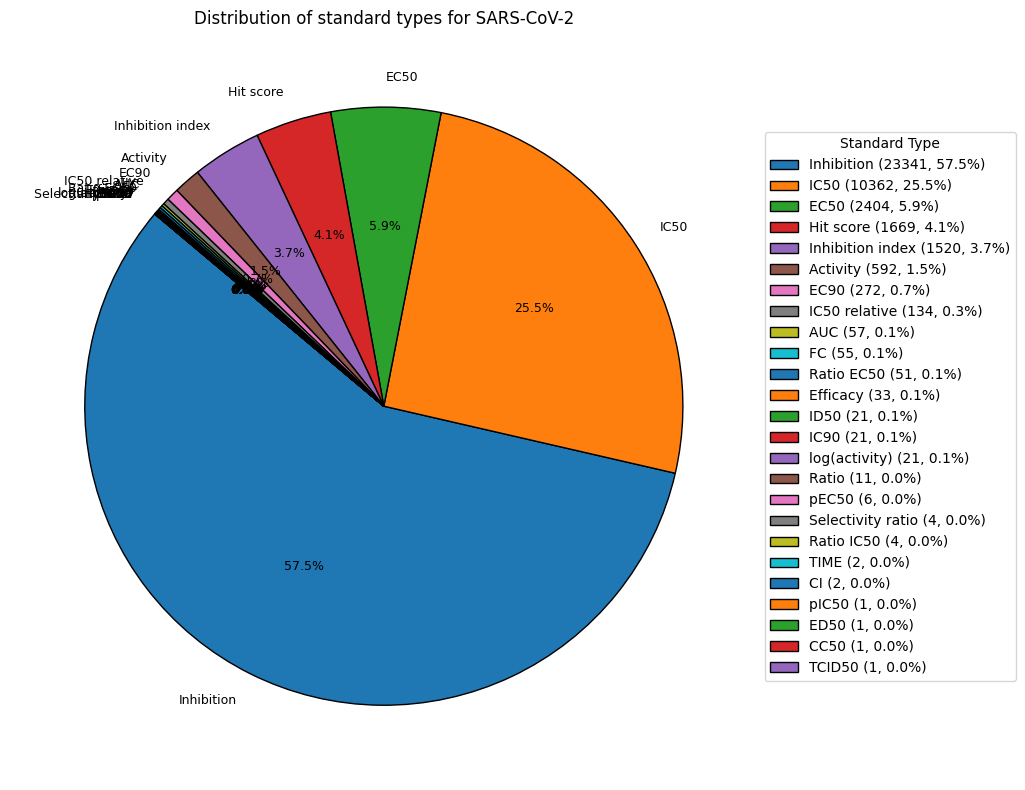


Checking for missing values
Smiles                   :    229 (  0.6%)
Standard Value           :    673 (  1.7%)
Standard Units           :  4,048 ( 10.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :    897 (  2.2%)
pChEMBL Value            : 37,824 ( 93.2%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :    136 (  0.3%)
AlogP                    :  1,098 (  2.7%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Unique compounds for SARS-CoV-2: 11952

Processing compound data
Reading ChEMBL CSV file: Database_Data_Raw/ChEMBL_data/SARS-CoV-2/SARS-CoV-2_compounds.csv
Compound data shape: (11838, 29)
Saved cleaned compound data to: Database_Data_Cleaned/SARS-CoV-2Compounds_chEMBL_cleaned.csv

Combining bioassay and compound data
Saved combined data to: Database_Data_Cleaned/SARS-CoV-2Data_chEMBL_combined.csv with shape (40586, 24)
SARS-CoV-2: 2.2s


In [10]:
for targetName in CONFIG["targets"]:
    targetDataDir = os.path.join(chemblDir, targetName)
    start = time.time()
    processTargetChemblData(targetName, targetDataDir, cleanedInputDataDir)
    print(f"{targetName}: {time.time() - start:.1f}s")

## 2. Combine per-target ChEMBL data

Concatenate the per target combined files into one master dataset, tagging each row with its target name so a single potency model can be trained across targets.

In [11]:
chemblCombinedFiles = [
    os.path.join(cleanedInputDataDir, f"{targetName}Data_chEMBL_combined.csv")
    for targetName in CONFIG["targets"]
]

dfList = []
for filePath in chemblCombinedFiles:
    if os.path.exists(filePath):
        df = pd.read_csv(filePath)
        targetName = os.path.basename(filePath).replace("Data_chEMBL_combined.csv", "")
        df["Target"] = targetName
        print(f"Loaded {os.path.basename(filePath):40s} shape: {df.shape}")
        dfList.append(df)
    else:
        print(f"File not found: {os.path.basename(filePath)}")

if dfList:
    allTargetData_chEMBL = pd.concat(dfList, ignore_index=True)
    print(f"\nCombined shape: {allTargetData_chEMBL.shape}")
    outFile = os.path.join(cleanedInputDataDir, "AllTargetData_chEMBL_combined.csv")
    allTargetData_chEMBL.to_csv(outFile, index=False)
    print(f"Saved merged CSV to: {outFile}")
else:
    allTargetData_chEMBL = pd.DataFrame()
    print("No per-target files were loaded.")

Loaded EbolaData_chEMBL_combined.csv            shape: (956, 25)
Loaded MarburgData_chEMBL_combined.csv          shape: (227, 25)
Loaded LassaData_chEMBL_combined.csv            shape: (234, 25)
Loaded NipahData_chEMBL_combined.csv            shape: (21, 25)
Loaded VEEVData_chEMBL_combined.csv             shape: (474, 25)
Loaded HantaData_chEMBL_combined.csv            shape: (157, 25)
Loaded SARS-CoVData_chEMBL_combined.csv         shape: (450, 25)
Loaded SARS-CoV-2Data_chEMBL_combined.csv       shape: (40586, 25)

Combined shape: (43105, 25)
Saved merged CSV to: Database_Data_Cleaned/AllTargetData_chEMBL_combined.csv


## 3. Standardize potency

Bioactivity is reported with many standard types and units. We keep only concentration endpoints (ICxx, ECxx, Ki, Kd), convert them to micromolar and then to a log potency scale.

`pPotency = pScaleOffset - log10(value in micromolar)`, which is equivalent to`-log10(value in molar)`

In [12]:
CONC_TYPE_PATTERNS = [
    r"\b[IE]C\s*\d+\b",   # IC50, EC90, and similar concentration endpoints
    r"\bK[di]\b",          # Ki or Kd binding constants
]

UNIT_TO_MICROMOLAR = {
    "M": 1e6,
    "mM": 1e3,
    "uM": 1.0, "μM": 1.0, "µM": 1.0,
    "nM": 1e-3,
    "pM": 1e-6,
}


def isConcentrationType(standardType):
    """Return True if a standard type is a concentration endpoint we can convert."""
    if not isinstance(standardType, str):
        return False
    collapsed = standardType.strip().replace(" ", "")
    return any(
        re.search(pattern, collapsed, flags=re.IGNORECASE) for pattern in CONC_TYPE_PATTERNS
    )


def toMicroMolar(value, unit):
    """Convert a value with a known unit to micromolar, or NaN when not possible."""
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    factor = UNIT_TO_MICROMOLAR.get(str(unit).strip())
    if factor is None:
        return np.nan
    try:
        return float(value) * factor
    except Exception:
        return np.nan


def addMicroMolarColumn(df):
    """Add a value_uM column for convertible concentration endpoints."""
    out = df.copy()
    isConcType = out["standard_type"].apply(isConcentrationType)
    hasKnownUnit = out["standard_units"].isin(UNIT_TO_MICROMOLAR.keys())
    isNumericValue = pd.to_numeric(out["standard_value"], errors="coerce").notna()
    isConvertible = isConcType & hasKnownUnit & isNumericValue

    out["value_uM"] = np.where(
        isConvertible,
        [toMicroMolar(v, u) for v, u in zip(out["standard_value"], out["standard_units"])],
        np.nan,
    )
    print("Convertible standards:", int(isConvertible.sum()))
    print("Non-convertible standards:", int((~isConvertible).sum()))
    return out


allTargetData_uM = addMicroMolarColumn(allTargetData_chEMBL)
allTargetData_uM = allTargetData_uM.dropna(subset=["value_uM"])
print("Shape after keeping convertible rows:", allTargetData_uM.shape)

Convertible standards: 14522
Non-convertible standards: 28583
Shape after keeping convertible rows: (14522, 26)


### Convert micromolar to the log potency scale

Relations are normalized first so that censored values are handled correctly:
`<` and `<=` give a lower bound on potency, `>` and `>=` give an upper bound, and
`=` or missing relations give an exact value.

In [13]:
def normalizeRelation(relation):
    """Normalize a standard-relation string to one of =, <, >, <=, >=, or None."""
    if pd.isna(relation):
        return None
    s = str(relation).strip()
    if (s.startswith("'") and s.endswith("'")) or (s.startswith('"') and s.endswith('"')):
        s = s[1:-1].strip()
    s = s.strip().lower()
    s = s.replace("&lt;", "<").replace("&gt;", ">")
    s = s.replace("≤", "<=").replace("≥", ">=")
    s = s.replace("==", "=")
    if s in {"eq", "equals", "equal"}:
        s = "="
    elif s in {"lt", "less", "lessthan"}:
        s = "<"
    elif s in {"le", "lessequal", "lessthanorequal"}:
        s = "<="
    elif s in {"gt", "greater", "greaterthan"}:
        s = ">"
    elif s in {"ge", "greaterequal", "greaterthanorequal"}:
        s = ">="
    elif s in {"approx", "~", "≈"}:
        s = "="
    if s in {"=", "<", ">", "<=", ">="}:
        return s
    return None


def safeLog10(x):
    """Elementwise log10 that returns NaN for non-positive values."""
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = x > 0
    out[mask] = np.log10(x[mask])
    return out


def addPPotency(df, pScaleOffset):
    """Add pPotency plus one-sided bounds for censored measurements."""
    out = df.copy()
    out["value_uM"] = pd.to_numeric(out.get("value_uM"), errors="coerce")
    out["relation_norm"] = out.get("standard_relation").apply(normalizeRelation)

    pFromMicroMolar = pScaleOffset - safeLog10(out["value_uM"])

    hasExact = out["relation_norm"].isna() | out["relation_norm"].eq("=")
    isLt = out["relation_norm"].eq("<")
    isLe = out["relation_norm"].eq("<=")
    isGt = out["relation_norm"].eq(">")
    isGe = out["relation_norm"].eq(">=")

    out["pPotency"] = np.where(hasExact, pFromMicroMolar, np.nan)
    out["pPotencyLower"] = np.where(isLt | isLe, pFromMicroMolar, np.nan)
    out["pPotencyUpper"] = np.where(isGt | isGe, pFromMicroMolar, np.nan)
    out["pPotencyMid"] = out[["pPotency", "pPotencyLower", "pPotencyUpper"]].median(
        axis=1, skipna=True
    )

    print("Exact pPotency rows:", int(out["pPotency"].notna().sum()))
    print("Censored lower-bound rows:", int(out["pPotencyLower"].notna().sum()))
    print("Censored upper-bound rows:", int(out["pPotencyUpper"].notna().sum()))
    return out


allTargetData_uM = addPPotency(allTargetData_uM, CONFIG["pScaleOffset"])

# Keep the exact-value pPotency as the modeling label; drop the helper bound columns.
allTargetData_uM = allTargetData_uM.drop(
    columns=["relation_norm", "pPotencyLower", "pPotencyUpper"], errors="ignore"
)
chemblOutPath = os.path.join(cleanedInputDataDir, "allTargetData_chEMBL_uM.csv")
allTargetData_uM.to_csv(chemblOutPath, index=False)
print("Saved standardized ChEMBL table to:", chemblOutPath)

Exact pPotency rows: 4705
Censored lower-bound rows: 61
Censored upper-bound rows: 9756
Saved standardized ChEMBL table to: Database_Data_Cleaned/allTargetData_chEMBL_uM.csv


## 4. Read PubChem data

PubChem bioassay data can come from two sources: CSV exports you have already
downloaded per target or  queries to the PubChem and NCBI E-utilities APIs.
Both paths are provided. 

Set your contact email and an NCBI API key in `CONFIG`.

### (4A) Load PubChem CSV exports from per target folders

In [14]:
def loadAllCsvsToOneDF(targetPubchemDir):
    """Concatenate every CSV in a folder into one DataFrame, tagging the source file."""
    targetPubchemDir = Path(targetPubchemDir)
    dfList = []
    for csvPath in sorted(targetPubchemDir.glob("*.csv")):
        try:
            df = pd.read_csv(csvPath, dtype=str, low_memory=False)
            df.insert(0, "sourceFile", csvPath.name)
            dfList.append(df)
        except Exception as error:
            print(f"[skip] {csvPath.name}: {error}")
    return pd.concat(dfList, ignore_index=True, sort=False) if dfList else pd.DataFrame()


# Map each target to a folder of PubChem CSV exports.
# TODO: adjust folder names to match your local PubChem download layout.
targetToPubchemDir = {
    targetName: os.path.join(pubchemDir, f"{targetName}")
    for targetName in CONFIG["targets"]
}

dfList = []
for targetName, targetDir in targetToPubchemDir.items():
    if os.path.isdir(targetDir):
        df = loadAllCsvsToOneDF(targetDir)
        if not df.empty:
            df["Target"] = targetName
            dfList.append(df)
    else:
        print(f"PubChem folder not found for {targetName}: {targetDir}")

allTarget_Pubchem = pd.concat(dfList, ignore_index=True, sort=False) if dfList else pd.DataFrame()
print("PubChem export shape:", allTarget_Pubchem.shape)

[skip] AID_540278.csv: No columns to parse from file
[skip] AID_463114.csv: No columns to parse from file
[skip] AID_540249.csv: No columns to parse from file
[skip] AID_588723.csv: No columns to parse from file


/tmp/ipykernel_1821665/1314889316.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Target"] = targetName


PubChem folder not found for Hanta: Database_Data_Raw/PubChem_data/Hanta
[skip] AID_1859.csv: No columns to parse from file
[skip] AID_485354.csv: No columns to parse from file
PubChem folder not found for SARS-CoV-2: Database_Data_Raw/PubChem_data/SARS-CoV-2
PubChem export shape: (1785473, 664)


### (B) Download PubChem bioassays through the NCBI and PubChem APIs

### Normalize PubChem units and compute pPotency

PubChem unit strings vary more than ChEMBL's, so units are normalized (handling
the micro sign, non-breaking spaces, and molar-per-litre aliases) before the same
log potency conversion is applied.

In [15]:
def normalizePubchemUnits(series):
    """Normalize PubChem unit strings to a compact lowercase form."""
    return (
        series.astype(str)
        .str.replace("\u00a0", " ", regex=False)
        .str.strip()
        .str.replace("µ", "u", regex=False)
        .str.replace(" ", "", regex=False)
        .str.lower()
    )


PUBCHEM_UNIT_TO_MOLAR = {
    "nm": 1e-9, "um": 1e-6, "mm": 1e-3, "m": 1.0,
    "umol/l": 1e-6, "nmol/l": 1e-9, "mmol/l": 1e-3, "mol/l": 1.0,
}

if not allTarget_Pubchem.empty:
    keepCols = [
        "PUBCHEM_CID", "PUBCHEM_EXT_DATASOURCE_SMILES", "PubChem Standard Value",
        "Standard Type", "Standard Relation", "Standard Value", "Standard Units", "Target",
    ]
    allTarget_Pubchem = allTarget_Pubchem[
        [c for c in keepCols if c in allTarget_Pubchem.columns]
    ].dropna(subset=["PUBCHEM_EXT_DATASOURCE_SMILES"])

    unitNormalized = normalizePubchemUnits(allTarget_Pubchem["Standard Units"])
    allTarget_Pubchem = allTarget_Pubchem[unitNormalized.isin(PUBCHEM_UNIT_TO_MOLAR)].copy()

    standardValueNum = pd.to_numeric(allTarget_Pubchem["Standard Value"], errors="coerce")
    molarFactor = normalizePubchemUnits(allTarget_Pubchem["Standard Units"]).map(
        PUBCHEM_UNIT_TO_MOLAR
    )
    valueMolar = standardValueNum * molarFactor
    allTarget_Pubchem["pPotency"] = np.where(
        valueMolar > 0, -np.log10(valueMolar), np.nan
    )

    allTarget_Pubchem = allTarget_Pubchem.rename(
        columns={"PUBCHEM_EXT_DATASOURCE_SMILES": "smiles", "PUBCHEM_CID": "compound_id"}
    )
    allTarget_Pubchem = allTarget_Pubchem[["Target", "compound_id", "smiles", "pPotency"]]
    print("PubChem standardized shape:", allTarget_Pubchem.shape)
else:
    print("No PubChem export loaded; skipping PubChem standardization.")

PubChem standardized shape: (32589, 4)


/users/sghosh6/.conda/envs/reinforcement_learning/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/users/sghosh6/.conda/envs/reinforcement_learning/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 5. Canonicalize SMILES and filter

Canonical SMILES make lookups and de-duplication reliable across sources. This
matters here because PubChem-serialized SMILES and RDKit-canonicalized SMILES
often differ, so both sides of any join should be canonicalized. We then keep
only valid structures with an in-range potency value.

In [16]:
def canonicalizeSmiles(smiles):
    """Return the RDKit canonical SMILES, or None for structures RDKit cannot parse."""
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) and smiles else None
    return Chem.MolToSmiles(mol, canonical=True) if mol else None


def isValidSmiles(smiles):
    """Return True if RDKit can parse the SMILES string."""
    if not isinstance(smiles, str) or not smiles:
        return False
    try:
        return Chem.MolFromSmiles(smiles) is not None
    except Exception:
        return False


smilesCol = CONFIG["smilesColumn"]
labelCol = CONFIG["labelColumn"]

# Standardize the ChEMBL table for modeling: canonical SMILES, valid rows, in-range label.
modelReady = allTargetData_uM.copy()
modelReady[smilesCol] = modelReady[smilesCol].astype(str).apply(canonicalizeSmiles)
modelReady = modelReady[modelReady[smilesCol].notna()]

before = modelReady.shape[0]
modelReady = modelReady[
    modelReady[labelCol].notna()
    & (modelReady[labelCol] > CONFIG["pPotencyMin"])
    & (modelReady[labelCol] < CONFIG["pPotencyMax"])
]
print(f"Rows after potency filter: {before} to {modelReady.shape[0]}")

modelReadyPath = os.path.join(cleanedInputDataDir, "allTargetData_modelReady.csv")
modelReady.to_csv(modelReadyPath, index=False)
print("Saved model ready table to:", modelReadyPath)

[15:55:42] SMILES Parse Error: syntax error while parsing: nan
[15:55:42] SMILES Parse Error: check for mistakes around position 2:
[15:55:42] nan
[15:55:42] ~^
[15:55:42] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:55:42] SMILES Parse Error: syntax error while parsing: nan
[15:55:42] SMILES Parse Error: check for mistakes around position 2:
[15:55:42] nan
[15:55:42] ~^
[15:55:42] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:55:42] SMILES Parse Error: syntax error while parsing: nan
[15:55:42] SMILES Parse Error: check for mistakes around position 2:
[15:55:42] nan
[15:55:42] ~^
[15:55:42] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:55:42] SMILES Parse Error: syntax error while parsing: nan
[15:55:42] SMILES Parse Error: check for mistakes around position 2:
[15:55:42] nan
[15:55:42] ~^
[15:55:42] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:55:43] SMILES Parse Error: syntax error while pa

Rows after potency filter: 14497 to 4694
Saved model ready table to: Database_Data_Cleaned/allTargetData_modelReady.csv


[15:55:45] SMILES Parse Error: syntax error while parsing: nan
[15:55:45] SMILES Parse Error: check for mistakes around position 2:
[15:55:45] nan
[15:55:45] ~^
[15:55:45] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:55:45] SMILES Parse Error: syntax error while parsing: nan
[15:55:45] SMILES Parse Error: check for mistakes around position 2:
[15:55:45] nan
[15:55:45] ~^
[15:55:45] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:55:45] SMILES Parse Error: syntax error while parsing: nan
[15:55:45] SMILES Parse Error: check for mistakes around position 2:
[15:55:45] nan
[15:55:45] ~^
[15:55:45] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:55:45] SMILES Parse Error: syntax error while parsing: nan
[15:55:45] SMILES Parse Error: check for mistakes around position 2:
[15:55:45] nan
[15:55:45] ~^
[15:55:45] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
